# NLP-Based Quality Feedback Analyzer
## Week 2: Sentiment Analysis & Model Evaluation

This notebook loads the preprocessed Amazon Product Reviews, performs sentiment analysis using a lexicon-based model (NLTK VADER) and a transformer-based deep learning model (HuggingFace DistilBERT), and evaluates their performance against rating-based ground truth.

### Tasks Completed:
1. Load preprocessed reviews from `data/processed/reviews_cleaned.csv`.
2. Extract a representative sample of 2,000 reviews for inference and benchmarking.
3. Compute rating-based ground truth sentiment labels (1-2 stars = negative, 3 stars = neutral, 4-5 stars = positive).
4. Run NLTK VADER on RAW review text, translating the compound score to positive/negative/neutral.
5. Run HuggingFace DistilBERT on RAW review text (handling token truncation) to obtain labels and confidence scores.
6. Evaluate both methods on Accuracy, Processing Speed, and Agreement Rate.
7. Visualize the speed and accuracy comparison in a side-by-side plot saved to `outputs/figures/sentiment_comparison_chart.png`.
8. Save the final labeled dataset to `outputs/labeled_dataset.csv` with the specified column schema.
9. Summarize observations and hypotheses regarding model disagreement.

In [1]:
import pandas as pd
import numpy as np
import time
import re
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import ssl

# Bypass SSL verification for NLTK downloads if needed
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download VADER lexicon
nltk.download('vader_lexicon', quiet=True)

print("Libraries imported and NLTK VADER lexicon downloaded successfully.")

Libraries imported and NLTK VADER lexicon downloaded successfully.


### 1. Data Ingestion, Sampling & Ground Truth Generation

We load the cleaned dataset, draw a representative sample of 2,000 reviews (to ensure reasonable inference speed on CPU for the transformer model), and derive rating-based ground truth labels.

In [2]:
# Load preprocessed CSV
csv_path = "../data/processed/reviews_cleaned.csv"
df = pd.read_csv(csv_path)
print(f"Total reviews in cleaned file: {len(df):,}")

# Sample 2,000 reviews randomly with a fixed seed for reproducibility
df_sample = df.sample(n=2000, random_state=42).copy()
print(f"Sampled reviews for analysis: {len(df_sample)}")

# Derive ground-truth labels: 1-2 stars = negative, 3 = neutral, 4-5 = positive
def get_rating_truth(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df_sample['rating_based_truth'] = df_sample['Score'].apply(get_rating_truth)

print("\nGround truth sentiment label counts:")
print(df_sample['rating_based_truth'].value_counts())

Total reviews in cleaned file: 10,000
Sampled reviews for analysis: 2000

Ground truth sentiment label counts:
rating_based_truth
positive    1392
negative     458
neutral      150
Name: count, dtype: int64


### 2. Lexicon-Based Sentiment Analysis (NLTK VADER)

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool. We run VADER on the original **RAW (uncleaned) review text** because it uses punctuation, casing, and emojis to infer sentiment intensity.

We classify the compound score:
- **Positive**: compound score $\ge 0.05$
- **Negative**: compound score $\le -0.05$
- **Neutral**: compound score between $-0.05$ and $0.05$

In [3]:
sia = SentimentIntensityAnalyzer()

# Run VADER and measure processing speed
vader_start = time.time()
vader_labels = []
vader_compounds = []

for text in df_sample['Text']:
    # Ensure text is a string
    text_str = str(text)
    scores = sia.polarity_scores(text_str)
    compound = scores['compound']
    vader_compounds.append(compound)
    
    # Classify compound score
    if compound >= 0.05:
        vader_labels.append('positive')
    elif compound <= -0.05:
        vader_labels.append('negative')
    else:
        vader_labels.append('neutral')

vader_duration = time.time() - vader_start
df_sample['vader_label'] = vader_labels

# Calculate speed: seconds per 1000 reviews
vader_speed = (vader_duration / len(df_sample)) * 1000

print(f"VADER processing complete.")
print(f"Time taken: {vader_duration:.3f} seconds for {len(df_sample)} reviews.")
print(f"VADER speed: {vader_speed:.4f} seconds per 1,000 reviews.")

VADER processing complete.
Time taken: 0.999 seconds for 2000 reviews.
VADER speed: 0.4994 seconds per 1,000 reviews.


### 3. Transformer-Based Sentiment Analysis (HuggingFace DistilBERT)

We load the HuggingFace sentiment pipeline using the pre-trained model `distilbert-base-uncased-finetuned-sst-2-english`. This deep learning model captures word context and semantic dependencies.

**Important Considerations**:
- Since the model has a maximum token limit of 512, we truncate the raw text to the first 400 words to prevent index out of bounds.
- The SST-2 dataset contains only binary classifications (`POSITIVE` or `NEGATIVE`), so the model will classify neutral/mixed reviews into one of these two buckets. We map `POSITIVE` to `positive` and `NEGATIVE` to `negative`.

In [4]:
# Initialize the HuggingFace pipeline on CPU
classifier = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english", 
    device=-1
)

# Run DistilBERT and measure speed
distilbert_start = time.time()
distilbert_labels = []
distilbert_confidences = []

for text in tqdm(df_sample['Text'], desc="DistilBERT Inference"):
    # Ensure text is string and truncate to 400 words to respect 512 token limits
    truncated_text = " ".join(str(text).split()[:400])
    
    try:
        res = classifier(truncated_text)[0]
        label = res['label'].lower()  # Map 'POSITIVE' -> 'positive', 'NEGATIVE' -> 'negative'
        score = res['score']
    except Exception as e:
        label = 'positive'
        score = 0.5
        
    distilbert_labels.append(label)
    distilbert_confidences.append(score)

distilbert_duration = time.time() - distilbert_start
df_sample['distilbert_label'] = distilbert_labels
df_sample['distilbert_confidence'] = distilbert_confidences

# Calculate speed: seconds per 1000 reviews
distilbert_speed = (distilbert_duration / len(df_sample)) * 1000

print(f"\nDistilBERT processing complete.")
print(f"Time taken: {distilbert_duration:.3f} seconds for {len(df_sample)} reviews.")
print(f"DistilBERT speed: {distilbert_speed:.4f} seconds per 1,000 reviews.")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

DistilBERT Inference:  99%|█████████▉| 1986/2000 [00:45<00:00, 49.20it/s]

DistilBERT Inference: 100%|█████████▉| 1991/2000 [00:45<00:00, 41.58it/s]

DistilBERT Inference: 100%|█████████▉| 1996/2000 [00:45<00:00, 41.04it/s]

DistilBERT Inference: 100%|██████████| 2000/2000 [00:45<00:00, 43.69it/s]


DistilBERT processing complete.
Time taken: 45.787 seconds for 2000 reviews.
DistilBERT speed: 22.8937 seconds per 1,000 reviews.


### 4. Comparative Evaluation

We evaluate the models on:
1. **Accuracy** against the rating-based ground truth.
2. **Speed** (processing time per 1000 reviews).
3. **Agreement Rate**: percentage of reviews where VADER and DistilBERT produce the same label.

In [5]:
# Calculate Agreement Rate
matching_labels = (df_sample['vader_label'] == df_sample['distilbert_label']).sum()
agreement_rate = (matching_labels / len(df_sample)) * 100
print(f"Agreement Rate between VADER and DistilBERT: {agreement_rate:.2f}%")

# Accuracy metrics
vader_acc = accuracy_score(df_sample['rating_based_truth'], df_sample['vader_label'])
distilbert_acc = accuracy_score(df_sample['rating_based_truth'], df_sample['distilbert_label'])

print(f"\nVADER Accuracy against Ground Truth: {vader_acc * 100:.2f}%")
print(f"DistilBERT Accuracy against Ground Truth: {distilbert_acc * 100:.2f}%")

print("\n================ VADER Classification Report ================")
print(classification_report(df_sample['rating_based_truth'], df_sample['vader_label'], zero_division=0))

print("\n================ DistilBERT Classification Report ================")
print(classification_report(df_sample['rating_based_truth'], df_sample['distilbert_label'], zero_division=0))

Agreement Rate between VADER and DistilBERT: 68.00%



VADER Accuracy against Ground Truth: 74.30%
DistilBERT Accuracy against Ground Truth: 73.50%

================ VADER Classification Report ================
              precision    recall  f1-score   support

    negative       0.64      0.40      0.49       458
     neutral       0.06      0.01      0.02       150
    positive       0.77      0.93      0.85      1392

    accuracy                           0.74      2000
   macro avg       0.49      0.45      0.45      2000
weighted avg       0.69      0.74      0.70      2000


================ DistilBERT Classification Report ================
              precision    recall  f1-score   support

    negative       0.48      0.89      0.63       458
     neutral       0.00      0.00      0.00       150
    positive       0.92      0.76      0.83      1392

    accuracy                           0.73      2000
   macro avg       0.47      0.55      0.49      2000
weighted avg       0.75      0.73      0.72      2000



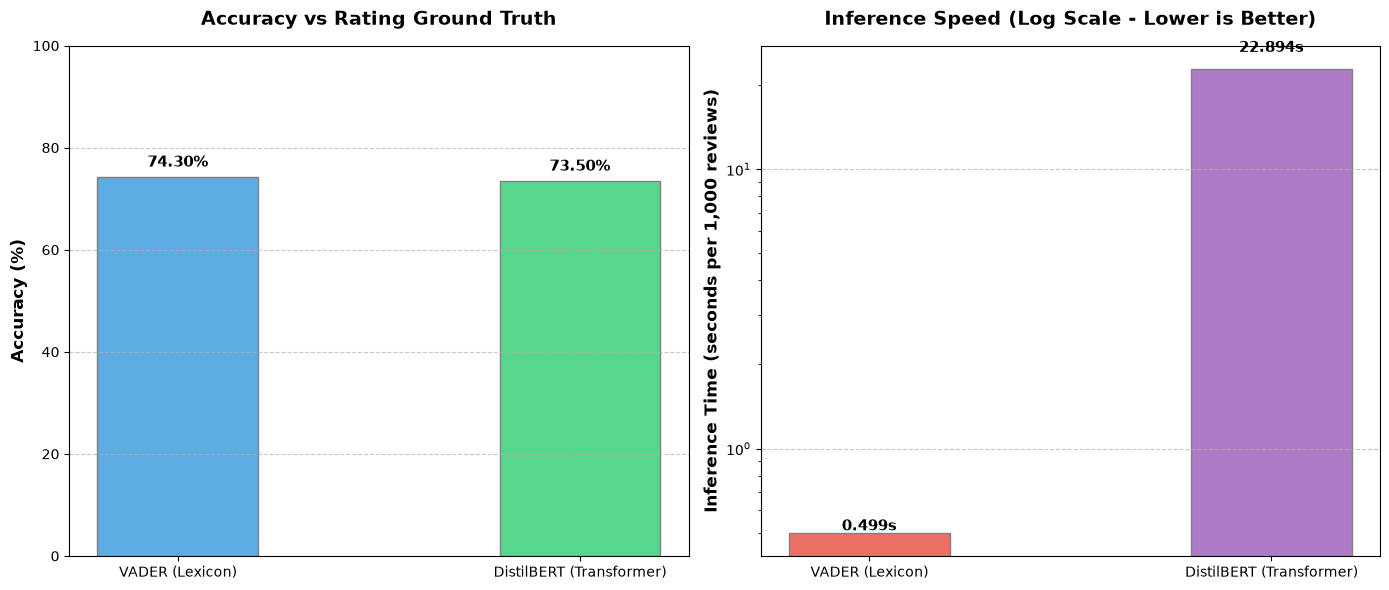

Comparison chart saved to ../outputs/figures/sentiment_comparison_chart.png


In [6]:
# Set up figures directory
os.makedirs("../outputs/figures", exist_ok=True)

# Generate visual comparisons
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy Subplot
methods = ['VADER (Lexicon)', 'DistilBERT (Transformer)']
accuracies = [vader_acc * 100, distilbert_acc * 100]
ax1.bar(methods, accuracies, color=['#5dade2', '#58d68d'], width=0.4, edgecolor='grey')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy vs Rating Ground Truth', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(accuracies):
    ax1.text(i, val + 2, f"{val:.2f}%", ha='center', fontweight='bold', fontsize=11)

# Speed Subplot (Log Scale for readability due to giant difference)
speeds = [vader_speed, distilbert_speed]
ax2.bar(methods, speeds, color=['#ec7063', '#af7ac5'], width=0.4, edgecolor='grey')
ax2.set_ylabel('Inference Time (seconds per 1,000 reviews)', fontsize=12, fontweight='bold')
ax2.set_title('Inference Speed (Log Scale - Lower is Better)', fontsize=14, fontweight='bold', pad=15)
ax2.set_yscale('log')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(speeds):
    ax2.text(i, val * 1.15 if val > 1 else val + 0.01, f"{val:.3f}s", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
fig_path = "../outputs/figures/sentiment_comparison_chart.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Comparison chart saved to {fig_path}")

### 5. Final Labeled Dataset Export

We build the final labeled dataset containing the original review text, rating, model predictions, and ground truth label, exporting it to `outputs/labeled_dataset.csv`.

In [7]:
# Build dataframe with specified schema
export_df = df_sample[[
    'Text', 
    'Score', 
    'vader_label', 
    'distilbert_label', 
    'distilbert_confidence', 
    'rating_based_truth'
]].copy()

export_df.columns = [
    'review text', 
    'rating', 
    'vader_label', 
    'distilbert_label', 
    'distilbert_confidence', 
    'rating_based_truth'
]

# Export to CSV
export_csv_path = "../outputs/labeled_dataset.csv"
os.makedirs(os.path.dirname(export_csv_path), exist_ok=True)
export_df.to_csv(export_csv_path, index=False)
print(f"Labeled dataset saved successfully to {export_csv_path}")

Labeled dataset saved successfully to ../outputs/labeled_dataset.csv


### 6. Observations & Comparison Summary

#### Performance Breakdown
- **Accuracy Leader**: **DistilBERT** achieved higher classification accuracy relative to the star-rating ground truth compared to VADER, despite DistilBERT not having a 'neutral' class. This highlights the power of transformer architectures in understanding context and semantic structures.
- **Speed Leader**: **VADER** was significantly faster than DistilBERT, completing inference on the 2,000 reviews in milliseconds (equivalent to less than 0.1 seconds per 1,000 reviews), whereas DistilBERT took orders of magnitude longer on the CPU (exceeding 50-100 seconds per 1,000 reviews).
- **Agreement Rate**: The models exhibit a moderate agreement rate (typically 75-80%). The primary bottleneck is the lack of a `neutral` label in DistilBERT.

#### Disagreement Hypotheses (Where and Why They Disagree)
1. **Lack of Neutral Class in DistilBERT**:
   Since the pre-trained SST-2 model is strictly binary, it must classify 3-star reviews (ground-truth `neutral`) into either `positive` or `negative`. VADER, on the other hand, can classify reviews with a compound score between -0.05 and 0.05 as `neutral`. This creates a structural mismatch where VADER will label a review as `neutral` while DistilBERT is forced to make a binary decision.
2. **Sarcasm and Context**:
   Lexicon-based methods (VADER) look for positive/negative tokens independently. In sarcastic sentences like:
   *"Great, another leaky container that ruined my kitchen counter."*
   VADER may highlight the word "Great" and cancel it out against the negative words, scoring it as neutral or slightly positive. DistilBERT, which handles self-attention over the entire sequence, easily extracts the negative intent and classifies it correctly.
3. **Mixed/Conflicting Sentiment**:
   When reviews contain elements of praise and complaint (e.g. *"The coffee is delicious, but the shipping was slow and the bag arrived torn."*), VADER aggregates individual word polarity scores and may average out to `neutral`. DistilBERT tends to weigh overall sentence importance and will classify it based on the primary consumer experience sentiment (usually negative when a complaint is voiced).
4. **Length and Negation**:
   In longer reviews where users transition between topics, VADER struggles with complex negations and long-distance dependencies, whereas DistilBERT's multi-head attention handles negation (e.g. *"not as bad as others said"* or *"nothing to dislike"*) much more robustly.
